## Open notebook in:
| Colab                                 |
|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nicolepcx/transformers-the-definitive-guide/blob/master/CH04/ch04_inference_PixArt-Sigma-XL.ipynb)                                                    

# About this notebook

This notebook how you can generate high-quality images using the PixArt-Σ model, a state-of-the-art diffusion transformer for ultra-high-resolution image synthesis.

You will also monitor GPU memory usage throughout the process, using [PyTorch's memory functionality](https://pytorch.org/docs/stable/torch_cuda_memory.html#), and employ strategies like freezing parts of the model and cleaning up unused resources to further optimize memory consumption. By the end of this notebook, you will have a practical understanding of how to handle large-scale models on limited hardware, enabling you to generate high-quality images with reduced memory overhead.

#Installs

In [ ]:
!pip -q install transformers==4.42.4 \
                diffusers==0.30.0 \
                bitsandbytes==0.43.3 \
                ftfy==6.2.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 130.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires n

#Imports

In [ ]:
import torch
from diffusers import PixArtSigmaPipeline


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


#Get Memory Summary

In [ ]:
print(
    torch.cuda.memory_summary()
)


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

#Initialize Memory tracking

In [ ]:
torch.cuda.memory._record_memory_history()

# Run Inference

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

pipe = PixArtSigmaPipeline.from_pretrained(
    "PixArt-alpha/PixArt-Sigma-XL-2-1024-MS", torch_dtype=torch.float16
).to(device)

def to_giga_bytes(bytes):
    return bytes / (1024 ** 3)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


model_index.json:   0%|          | 0.00/400 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

In [ ]:
print(
    f"Max memory allocated: {to_giga_bytes(torch.cuda.max_memory_allocated())} GB"
)

print(
    f"Max memory reserved: {to_giga_bytes(torch.cuda.memory_reserved())} GB"
)

Max memory allocated: 12.065927028656006 GB
Max memory reserved: 12.228515625 GB


In [ ]:
prompt = "Cute animated tabby with big eyes"
generator = torch.Generator(device=device).manual_seed(42)
image = pipe(prompt, generator=generator).images[0]
image.save("./tabby.png")


Setting `clean_caption=True` requires the ftfy library but it was not found in your environment. Checkout the instructions on the
installation section: https://github.com/rspeer/python-ftfy/tree/master#installing and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.

Setting `clean_caption` to False...

Setting `clean_caption=True` requires the ftfy library but it was not found in your environment. Checkout the instructions on the
installation section: https://github.com/rspeer/python-ftfy/tree/master#installing and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.

Setting `clean_caption` to False...


  0%|          | 0/20 [00:00<?, ?it/s]

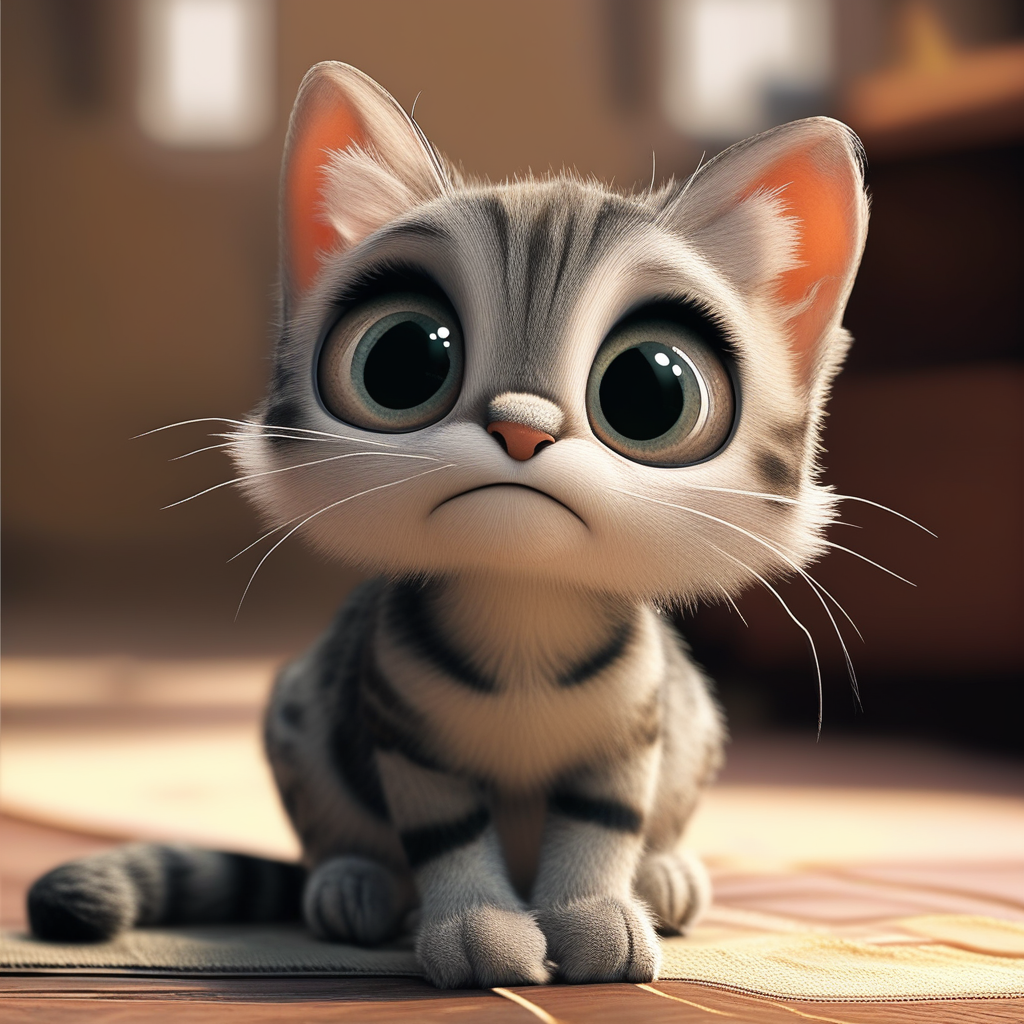

In [ ]:
image

In [ ]:
torch.cuda.memory._dump_snapshot("PixArtSigma.pickle")